# Cloud ETL Pipeline — Notebook 1: Pipeline Walkthrough

**Author:** Mike Ichikawa  
**Date:** February 2026

This notebook walks through each stage of the ETL pipeline interactively:
Extract → Transform → Load, with inspection at every step.

Run in **LOCAL_MODE** (no AWS account needed) or with real AWS credentials.

```bash
LOCAL_MODE=true jupyter notebook
```

In [1]:
import sys, os
sys.path.insert(0, '..')
os.environ.setdefault('LOCAL_MODE', 'true')   # remove this line to use real AWS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date, timedelta

import config
from src.extract import extract_all_cities
from src.transform import transform_records
from src.load import S3Loader

plt.rcParams.update({'figure.facecolor': 'white', 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

print(f'LOCAL_MODE: {config.LOCAL_MODE}')
print(f'Cities configured: {len(config.CITIES)}')
print(f'Cities: {[c[0] for c in config.CITIES]}')

LOCAL_MODE: True
Cities configured: 10
Cities: ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 'San Antonio', 'San Diego', 'Dallas', 'Portland']


---
## Stage 1: Extract

Fetch daily weather summaries for all 10 cities from Open-Meteo.
The archive API returns real historical data — no synthetic data here.

In [2]:
# Extract for a specific historical date (archive API — always available)
target_date = '2026-01-15'

print(f'Extracting weather data for {target_date}...')
records = extract_all_cities(target_date)
print(f'Successfully fetched: {len(records)}/{len(config.CITIES)} cities')

Extracting weather data for 2026-01-15...
Successfully fetched: 10/10 cities


In [3]:
# Inspect one raw record
import json
print('Sample raw record (Portland):')
portland = next((r for r in records if r['city'] == 'Portland'), records[0])
print(json.dumps({k: v for k, v in portland.items() if k != 'description'}, indent=2))

Sample raw record (Portland):
{
  "city": "Portland",
  "latitude": 45.5051,
  "longitude": -122.675,
  "timezone": "America/Los_Angeles",
  "date": "2026-01-15",
  "source_url": "https://archive-api.open-meteo.com/v1/archive",
  "fetch_ms": 714.2,
  "fetched_at": "2026-02-20T20:00:22.815591Z",
  "temperature_2m_max": 12.4,
  "temperature_2m_min": 4.3,
  "temperature_2m_mean": 7.1,
  "precipitation_sum": 0.0,
  "wind_speed_10m_max": 18.6,
  "wind_gusts_10m_max": 40.3,
  "shortwave_radiation_sum": 6.85,
  "et0_fao_evapotranspiration": 1.01
}


In [4]:
# Quick raw data summary
raw_df = pd.DataFrame(records)
print('Raw extraction summary:')
print(raw_df[['city', 'temperature_2m_mean', 'precipitation_sum',
              'wind_speed_10m_max', 'fetch_ms']].to_string(index=False))

Raw extraction summary:
        city  temperature_2m_mean  precipitation_sum  wind_speed_10m_max  fetch_ms
    New York                  1.9                0.1                19.7     735.5
 Los Angeles                 15.5                0.0                 8.6     716.2
     Chicago                 -7.6                0.5                22.8     767.4
     Houston                  9.0                0.0                13.4     733.3
     Phoenix                 17.8                0.0                 8.6     721.3
Philadelphia                  0.7                1.7                21.0     725.2
 San Antonio                 11.5                0.0                12.3     764.9
   San Diego                 16.3                0.0                 8.3    1882.0
      Dallas                  8.1                0.0                16.8     723.8
    Portland                  7.1                0.0                18.6     714.2


---
## Stage 2: Transform

Clean, enrich, and add derived features: heat index, temp range, wind/precip categories, anomaly flags.

In [5]:
df = transform_records(records, run_id='nb_walkthrough_001')

print(f'Transform complete: {len(df)} rows, {len(df.columns)} columns')
print(f'\nNew derived columns:')
derived = ['temp_range_c', 'heat_index', 'precipitation_category',
           'wind_category', 'price_tier', 'is_extreme_temp', 'is_heavy_rain', 'is_high_wind']
for col in derived:
    if col in df.columns:
        print(f'  {col}: {df[col].values}')

Transform complete: 10 rows, 23 columns

New derived columns:
  temp_range_c: [11.2 17.2  4.7  9.8 14.3 10.4 13.3 14.8 13.5  8.1]
  heat_index: [ 60.03  28.39 101.73  39.39  26.3   64.41  34.26  27.56  41.51  44.03]
  precipitation_category: ['light' 'none' 'light' 'none' 'none' 'light' 'none' 'none' 'none' 'none']
  wind_category: ['calm' 'calm' 'breezy' 'calm' 'calm' 'breezy' 'calm' 'calm' 'calm' 'calm']
  is_extreme_temp: [False False False False False False False False False False]
  is_heavy_rain: [False False False False False False False False False False]
  is_high_wind: [False False False False False False False False False False]


In [6]:
# Show enriched data
display_cols = ['city', 'avg_temp_c', 'max_temp_c', 'min_temp_c', 'temp_range_c',
                'heat_index', 'precipitation_mm', 'precipitation_category',
                'wind_speed_max_kmh', 'wind_category', 'is_heavy_rain', 'is_high_wind']
print(df[display_cols].to_string(index=False))

        city  avg_temp_c  max_temp_c  min_temp_c  temp_range_c  heat_index  precipitation_mm precipitation_category  wind_speed_max_kmh wind_category  is_heavy_rain  is_high_wind
    New York         1.9         6.6        -4.6          11.2       60.03               0.1                  light                19.7          calm          False         False
 Los Angeles        15.5        25.4         8.2          17.2       28.39               0.0                   none                 8.6          calm          False         False
     Chicago        -7.6        -5.4       -10.1           4.7      101.73               0.5                  light                22.8        breezy          False         False
     Houston         9.0        13.6         3.8           9.8       39.39               0.0                   none                13.4          calm          False         False
     Phoenix        17.8        25.2        10.9          14.3       26.30               0.0             

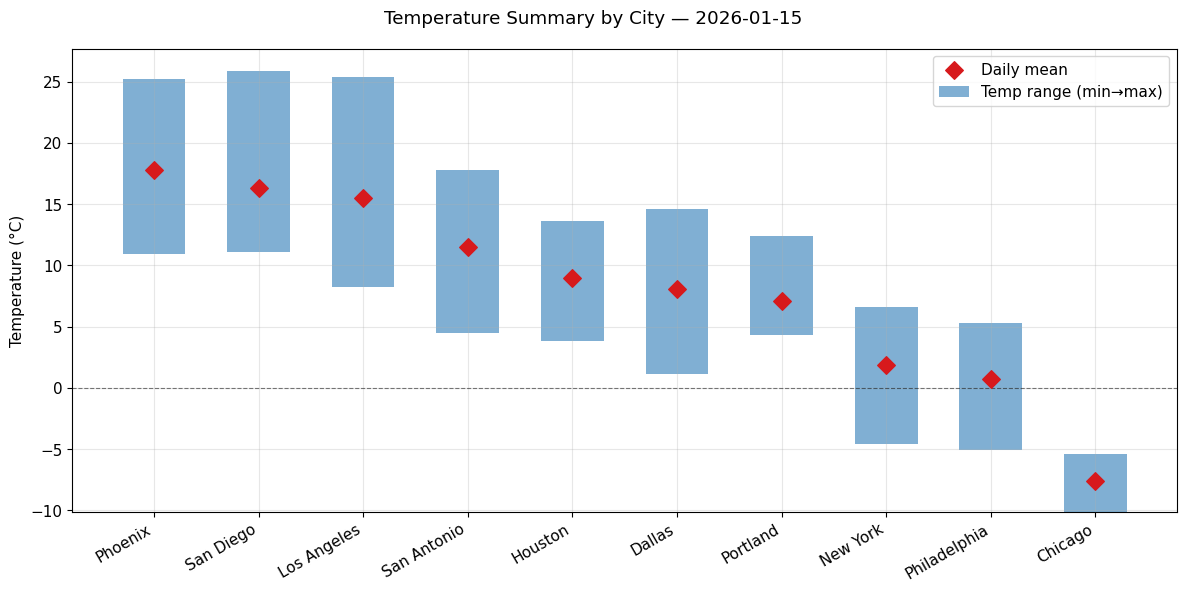

In [7]:
# Visualize temperature range by city
df_sorted = df.sort_values('avg_temp_c', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle(f'Temperature Summary by City — {target_date}')

x = range(len(df_sorted))
ax.bar(x, df_sorted['temp_range_c'], bottom=df_sorted['min_temp_c'],
       color='#2C7BB6', alpha=0.6, label='Temp range (min→max)', width=0.6)
ax.scatter(x, df_sorted['avg_temp_c'], color='#D7191C', zorder=5, s=80,
           label='Daily mean', marker='D')

ax.set_xticks(x)
ax.set_xticklabels(df_sorted['city'], rotation=30, ha='right')
ax.set_ylabel('Temperature (°C)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig('../data/outputs/nb1_temp_by_city.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Stage 3: Load to S3

Upload raw JSON (per city) and processed Parquet to S3.
In LOCAL_MODE this writes to `data/raw/` and `data/processed/`.

In [8]:
loader = S3Loader()

# Upload raw
raw_keys = loader.upload_raw(records, target_date)
print(f'Raw uploads: {len(raw_keys)}')
for k in raw_keys[:3]:
    print(f'  {k}')
print('  ...')

Raw uploads: 10
  /Users/michaelichikawa/code/github_project/projects-hub/cloud-etl-pipeline/notebooks/../data/raw/year=2026/month=01/day=15/new_york.json
  /Users/michaelichikawa/code/github_project/projects-hub/cloud-etl-pipeline/notebooks/../data/raw/year=2026/month=01/day=15/los_angeles.json
  /Users/michaelichikawa/code/github_project/projects-hub/cloud-etl-pipeline/notebooks/../data/raw/year=2026/month=01/day=15/chicago.json
  ...


In [9]:
# Upload processed Parquet
processed_uri = loader.upload_processed(df, target_date)
print(f'Processed upload: {processed_uri}')

# Verify roundtrip: read it back
df_readback = loader.read_processed(target_date)
print(f'\nReadback shape: {df_readback.shape}')
print(f'Readback dtypes OK: {list(df_readback.dtypes.index)[:5]}')

Processed upload: /Users/michaelichikawa/code/github_project/projects-hub/cloud-etl-pipeline/notebooks/../data/processed/weather_enriched_20260115.parquet

Readback shape: (10, 23)
Readback dtypes OK: ['city', 'latitude', 'longitude', 'timezone', 'date']


In [10]:
# Log the run
loader.log_run({
    'run_id': 'nb_walkthrough_001',
    'date': target_date,
    'cities_extracted': len(records),
    'cities_failed': len(config.CITIES) - len(records),
    'extreme_events': int(df['is_extreme_temp'].sum()),
    'processed_uri': processed_uri,
    'duration_seconds': 4.2,
    'status': 'success',
})
print('Run logged.')

Run logged.


---
## S3 Data Layout Verification

Check the Hive-partitioned key structure.

In [11]:
# Show the key patterns
test_date = '2026-02-01'
print('S3 key patterns for', test_date)
print(f'  Raw (Portland):  {config.s3_raw_key("portland", test_date)}')
print(f'  Processed:       {config.s3_processed_key(test_date)}')
print(f'  Manifest:        {config.s3_manifest_key(test_date)}')

if config.LOCAL_MODE:
    import os
    print(f'\nLocal processed files:')
    for f in sorted(config.PROCESSED_DIR.glob('*.parquet')):
        size = f.stat().st_size / 1024
        print(f'  {f.name} ({size:.1f} KB)')

S3 key patterns for 2026-02-01
  Raw (Portland):  raw/weather/year=2026/month=02/day=01/portland.json
  Processed:       processed/weather_enriched/year=2026/month=02/day=01/weather_enriched_20260201.parquet
  Manifest:        manifests/manifest_20260201.json

Local processed files:
  weather_enriched_20260115.parquet (16.5 KB)
  weather_enriched_20260220.parquet (16.4 KB)
